# Test to get this 'Csordas' subnetwork method working

Input test command for **"permuted MNIST**:

main.py -name transfer_sharing -task permuted_mnist -stop_after 30000 -mask_loss_weight 0.00128 -lr 0.01 -mask_init 2 -layer_sizes 800,800,64

In [1]:
import torch
import torchvision

torch.__version__

'2.5.1'

In [2]:
torch.__version__

'2.5.1'

In [2]:
import framework
import tasks
import os
import torch

In [3]:
path = "./save/cifar10/checkpoint/model-220011.pth"
test = torch.load(path, weights_only=False)

In [4]:
for k in test["model"].keys():
    print(k)

model_parameters.features_0_bias
model_parameters.features_0_weight
model_parameters.features_10_bias
model_parameters.features_10_weight
model_parameters.features_3_bias
model_parameters.features_3_weight
model_parameters.features_6_bias
model_parameters.features_6_weight
model_parameters.out_layer_bias
model_parameters.out_layer_weight
masks.0.features_0_bias
masks.0.features_0_weight
masks.0.features_10_bias
masks.0.features_10_weight
masks.0.features_3_bias
masks.0.features_3_weight
masks.0.features_6_bias
masks.0.features_6_weight
masks.0.out_layer_bias
masks.0.out_layer_weight
masks.1.features_0_bias
masks.1.features_0_weight
masks.1.features_10_bias
masks.1.features_10_weight
masks.1.features_3_bias
masks.1.features_3_weight
masks.1.features_6_bias
masks.1.features_6_weight
masks.1.out_layer_bias
masks.1.out_layer_weight
masks.2.features_0_bias
masks.2.features_0_weight
masks.2.features_10_bias
masks.2.features_10_weight
masks.2.features_3_bias
masks.2.features_3_weight
masks.2.

In [5]:
# Fake run the test command to populate 'sys.argv'

import shlex
import sys

cmd = "main.py -name cifar10 -task cifar10_class_removal -stop_after 20000 -mask_loss_weight 3e-4 -mask_lr 1e-3 -step_per_mask 20000 -class_removal.keep_last_layer 1 -dropout 0.0 -cnn.dropout 0 -restore_pretrained ./save/cifar10/model_weights"
cmd_args = shlex.split(cmd)
sys.argv = cmd_args

print(cmd_args)

['main.py', '-name', 'cifar10', '-task', 'cifar10_class_removal', '-stop_after', '20000', '-mask_loss_weight', '3e-4', '-mask_lr', '1e-3', '-step_per_mask', '20000', '-class_removal.keep_last_layer', '1', '-dropout', '0.0', '-cnn.dropout', '0', '-restore_pretrained', './save/cifar10/model_weights']


In [6]:
from main import register_args, load_weights, save_weights

training_helper = framework.helpers.TrainingHelper(
    wandb_project_name="modules",
    register_args=register_args, 
    extra_dirs=["export", "model_weights"])

There is no more free GPUs. Allocating the one with least memory usage.


In [7]:
import numpy as np

np.random.RandomState(123)

RandomState(MT19937) at 0x7F44AAA30840

In [8]:
# All arguments from the arg-parser
training_helper.opt

{'name': 'cifar10',
 'reset': False,
 'log': 'tb',
 'save_interval': None,
 'seed': None,
 'gpu': 'auto',
 'keep_alive': False,
 'sweep_id_for_grid_search': 0,
 'batch_size': 128,
 'lr': 0.001,
 'wd': 0.0,
 'lr_warmup': 0,
 'mask_lr': 0.001,
 'test_interval': 1000,
 'n_digits': 1,
 'state_size': 128,
 'n_layers': 2,
 'stop_after': 20000,
 'task': 'cifar10_class_removal',
 'mask_loss_weight': 0.0003,
 'step_per_mask': 20000,
 'bias_no_mask': False,
 'dropout': 0.0,
 'tuple': {'mode': 'together', 'tuple2_delay': 0},
 'grad_clip': 1.0,
 'scan': {'analyze_splits': ['jump', 'length', 'turn_left'],
  'train_split': ['simple']},
 'scale_mask_loss': False,
 'mask_init': 2.0,
 'analysis': {'enable': True,
  'plot_masks': True,
  'only_verify_masks': False,
  'skip_layernorm': False},
 'layer_sizes': [800, 800, 256],
 'class_removal': {'keep_last_layer': True},
 'encoder_decoder': {'embedding_size': 16},
 'transfer': {'mask_new_init': 2.0,
  'mask_used_init': 2.0,
  'reset_first_layer': True},
 

In [9]:
def invalid_task_error(self):
    assert False, f"Invalid task: {training_helper.opt.task}"

In [10]:
constructors = {
    "tuple": tasks.TupleTask,
    "tuple_ff": tasks.TupleTaskFeedforward,
    "scan": tasks.ScanTask,
    "trafo_scan": tasks.TransformerScanTask,
    "addmul_ff": tasks.AddMulFeedforward,
    "addmul": tasks.AddMulTask,
    "cifar10_class_removal": tasks.Cifar10ClassRemovalTask,
    "cifar10_resnet_hp_class_removal": tasks.Cifar10ResnetHPClassRemovalTask,
    "cifar10_mask_stability": tasks.Cifar10MaskStabilityTask,
    "cifar10_grad_cos_distance": tasks.Cifar10GradCosDistanceTask,
    "permuted_mnist": tasks.PermutedMnistTask,
    "deepmind_math": tasks.DeepmindMathTask,
    "tuple_ff_copyweight": tasks.TupleFeedforwardCopyweightTask
}

In [11]:
task = constructors.get(training_helper.opt.task, invalid_task_error)(training_helper)

#########################
DROPOUT:
False
#########################
Found module parameters: ['features_0_bias', 'features_0_weight', 'features_10_bias', 'features_10_weight', 'features_3_bias', 'features_3_weight', 'features_6_bias', 'features_6_weight', 'out_layer_bias', 'out_layer_weight']
Masking is applied to paramteres: {'features_3_weight', 'features_6_weight', 'features_3_bias', 'features_0_weight', 'features_0_bias', 'features_10_weight', 'features_6_bias', 'features_10_bias', 'out_layer_weight', 'out_layer_bias'}
Masking 390986 out of 390986 parameters (100.0 %)


/home/gulmar/miniconda3/envs/test_csordas/lib/python3.12/site-packages/torch/utils/data/sampler.py:76: UserWarning: `data_source` argument is not used and will be removed in 2.2.0.You may still have custom implementation that utilizes it.
  warnings.warn(


In [12]:
if training_helper.opt.restore_pretrained:
    assert not task.helper.opt.train_baseline
    load_weights(training_helper, task)
    if training_helper.opt.test_pretrained:
        training_helper.summary.log({f"load_validation/{k}": v for k, v in task.validate().items()})
    print("Done. Skipping training...")
else:
    if task.helper.opt.train_baseline:
        task.set_baseline_mode()

    task.train()

    print("Training finished. Saving model...")
    save_weights(training_helper, task)

/home/gulmar/Library/Projects/Csordas_modules/main.py:166: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(pretrained)


Loading pretrained weights from ./save/cifar10/model_weights/model.pth...


100%|██████████| 78/78 [00:00<00:00, 111.69it/s]


Validation accuracy on iid: 0.7698803659394793


100%|██████████| 78/78 [00:00<00:00, 267.39it/s]


Validation accuracy on train: 0.9890419221875942
Done. Skipping training...


In [13]:
task.model

MaskedModel(
  (model_parameters): ParameterDict(
      (features_0_bias): Parameter containing: [torch.cuda.FloatTensor of size 32 (cuda:0)]
      (features_0_weight): Parameter containing: [torch.cuda.FloatTensor of size 32x3x3x3 (cuda:0)]
      (features_10_bias): Parameter containing: [torch.cuda.FloatTensor of size 256 (cuda:0)]
      (features_10_weight): Parameter containing: [torch.cuda.FloatTensor of size 256x128x3x3 (cuda:0)]
      (features_3_bias): Parameter containing: [torch.cuda.FloatTensor of size 64 (cuda:0)]
      (features_3_weight): Parameter containing: [torch.cuda.FloatTensor of size 64x32x3x3 (cuda:0)]
      (features_6_bias): Parameter containing: [torch.cuda.FloatTensor of size 128 (cuda:0)]
      (features_6_weight): Parameter containing: [torch.cuda.FloatTensor of size 128x64x3x3 (cuda:0)]
      (out_layer_bias): Parameter containing: [torch.cuda.FloatTensor of size 10 (cuda:0)]
      (out_layer_weight): Parameter containing: [torch.cuda.FloatTensor of size 1

In [14]:
task.model.masks[1]

ParameterDict(
    (features_0_bias): Parameter containing: [torch.cuda.FloatTensor of size 32 (cuda:0)]
    (features_0_weight): Parameter containing: [torch.cuda.FloatTensor of size 32x3x3x3 (cuda:0)]
    (features_10_bias): Parameter containing: [torch.cuda.FloatTensor of size 256 (cuda:0)]
    (features_10_weight): Parameter containing: [torch.cuda.FloatTensor of size 256x128x3x3 (cuda:0)]
    (features_3_bias): Parameter containing: [torch.cuda.FloatTensor of size 64 (cuda:0)]
    (features_3_weight): Parameter containing: [torch.cuda.FloatTensor of size 64x32x3x3 (cuda:0)]
    (features_6_bias): Parameter containing: [torch.cuda.FloatTensor of size 128 (cuda:0)]
    (features_6_weight): Parameter containing: [torch.cuda.FloatTensor of size 128x64x3x3 (cuda:0)]
    (out_layer_bias): Parameter containing: [torch.cuda.FloatTensor of size 10 (cuda:0)]
    (out_layer_weight): Parameter containing: [torch.cuda.FloatTensor of size 10x256 (cuda:0)]
)

In [15]:
len(task.model.masks)

11

In [16]:
for i in range(len(task.model.masks)):
    print(task.model.masks[i].keys())

dict_keys(['features_0_bias', 'features_0_weight', 'features_10_bias', 'features_10_weight', 'features_3_bias', 'features_3_weight', 'features_6_bias', 'features_6_weight', 'out_layer_bias', 'out_layer_weight'])
dict_keys(['features_0_bias', 'features_0_weight', 'features_10_bias', 'features_10_weight', 'features_3_bias', 'features_3_weight', 'features_6_bias', 'features_6_weight', 'out_layer_bias', 'out_layer_weight'])
dict_keys(['features_0_bias', 'features_0_weight', 'features_10_bias', 'features_10_weight', 'features_3_bias', 'features_3_weight', 'features_6_bias', 'features_6_weight', 'out_layer_bias', 'out_layer_weight'])
dict_keys(['features_0_bias', 'features_0_weight', 'features_10_bias', 'features_10_weight', 'features_3_bias', 'features_3_weight', 'features_6_bias', 'features_6_weight', 'out_layer_bias', 'out_layer_weight'])
dict_keys(['features_0_bias', 'features_0_weight', 'features_10_bias', 'features_10_weight', 'features_3_bias', 'features_3_weight', 'features_6_bias', 

In [17]:
task.model.masks[2]["features_6_weight"]

Parameter containing:
tensor([[[[2., 2., 2.],
          [2., 2., 2.],
          [2., 2., 2.]],

         [[2., 2., 2.],
          [2., 2., 2.],
          [2., 2., 2.]],

         [[2., 2., 2.],
          [2., 2., 2.],
          [2., 2., 2.]],

         ...,

         [[2., 2., 2.],
          [2., 2., 2.],
          [2., 2., 2.]],

         [[2., 2., 2.],
          [2., 2., 2.],
          [2., 2., 2.]],

         [[2., 2., 2.],
          [2., 2., 2.],
          [2., 2., 2.]]],


        [[[2., 2., 2.],
          [2., 2., 2.],
          [2., 2., 2.]],

         [[2., 2., 2.],
          [2., 2., 2.],
          [2., 2., 2.]],

         [[2., 2., 2.],
          [2., 2., 2.],
          [2., 2., 2.]],

         ...,

         [[2., 2., 2.],
          [2., 2., 2.],
          [2., 2., 2.]],

         [[2., 2., 2.],
          [2., 2., 2.],
          [2., 2., 2.]],

         [[2., 2., 2.],
          [2., 2., 2.],
          [2., 2., 2.]]],


        [[[2., 2., 2.],
          [2., 2., 2.],
        

In [18]:
task.get_n_masks()

11

In [19]:
task.mask_classes

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [20]:
task.helper.opt.class_removal.keep_last_layer

True

In [21]:
task.model.masks

ModuleList(
  (0-10): 11 x ParameterDict(
      (features_0_bias): Parameter containing: [torch.cuda.FloatTensor of size 32 (cuda:0)]
      (features_0_weight): Parameter containing: [torch.cuda.FloatTensor of size 32x3x3x3 (cuda:0)]
      (features_10_bias): Parameter containing: [torch.cuda.FloatTensor of size 256 (cuda:0)]
      (features_10_weight): Parameter containing: [torch.cuda.FloatTensor of size 256x128x3x3 (cuda:0)]
      (features_3_bias): Parameter containing: [torch.cuda.FloatTensor of size 64 (cuda:0)]
      (features_3_weight): Parameter containing: [torch.cuda.FloatTensor of size 64x32x3x3 (cuda:0)]
      (features_6_bias): Parameter containing: [torch.cuda.FloatTensor of size 128 (cuda:0)]
      (features_6_weight): Parameter containing: [torch.cuda.FloatTensor of size 128x64x3x3 (cuda:0)]
      (out_layer_bias): Parameter containing: [torch.cuda.FloatTensor of size 10 (cuda:0)]
      (out_layer_weight): Parameter containing: [torch.cuda.FloatTensor of size 10x256 (c

In [22]:
stage = 1
names = list(sorted(task.model.masks[stage].keys()))
last_layer_prefix = "out_layer_"

copy_names = [n for n in names if n.startswith(last_layer_prefix)]
optimize_names = [n for n in names if not n.startswith(last_layer_prefix)]

In [23]:
names

['features_0_bias',
 'features_0_weight',
 'features_10_bias',
 'features_10_weight',
 'features_3_bias',
 'features_3_weight',
 'features_6_bias',
 'features_6_weight',
 'out_layer_bias',
 'out_layer_weight']

In [24]:
print(copy_names)
print(optimize_names)

['out_layer_bias', 'out_layer_weight']
['features_0_bias', 'features_0_weight', 'features_10_bias', 'features_10_weight', 'features_3_bias', 'features_3_weight', 'features_6_bias', 'features_6_weight']


In [25]:
[task.model.masks[stage][n] for n in optimize_names]

[Parameter containing:
 tensor([2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
         2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.],
        device='cuda:0', requires_grad=True),
 Parameter containing:
 tensor([[[[2., 2., 2.],
           [2., 2., 2.],
           [2., 2., 2.]],
 
          [[2., 2., 2.],
           [2., 2., 2.],
           [2., 2., 2.]],
 
          [[2., 2., 2.],
           [2., 2., 2.],
           [2., 2., 2.]]],
 
 
         [[[2., 2., 2.],
           [2., 2., 2.],
           [2., 2., 2.]],
 
          [[2., 2., 2.],
           [2., 2., 2.],
           [2., 2., 2.]],
 
          [[2., 2., 2.],
           [2., 2., 2.],
           [2., 2., 2.]]],
 
 
         [[[2., 2., 2.],
           [2., 2., 2.],
           [2., 2., 2.]],
 
          [[2., 2., 2.],
           [2., 2., 2.],
           [2., 2., 2.]],
 
          [[2., 2., 2.],
           [2., 2., 2.],
           [2., 2., 2.]]],
 
 
         [[[2., 2., 2.],
           [2., 2., 2.],


In [26]:
for cn in copy_names:
    print(task.model.masks[stage][cn])#.copy_(task.model.masks[0][cn])

Parameter containing:
tensor([2., 2., 2., 2., 2., 2., 2., 2., 2., 2.], device='cuda:0',
       requires_grad=True)
Parameter containing:
tensor([[2., 2., 2.,  ..., 2., 2., 2.],
        [2., 2., 2.,  ..., 2., 2., 2.],
        [2., 2., 2.,  ..., 2., 2., 2.],
        ...,
        [2., 2., 2.,  ..., 2., 2., 2.],
        [2., 2., 2.,  ..., 2., 2., 2.],
        [2., 2., 2.,  ..., 2., 2., 2.]], device='cuda:0', requires_grad=True)


In [27]:
for cn in copy_names:
    print(task.model.masks[0][cn])

Parameter containing:
tensor([2., 2., 2., 2., 2., 2., 2., 2., 2., 2.], device='cuda:0',
       requires_grad=True)
Parameter containing:
tensor([[2., 2., 2.,  ..., 2., 2., 2.],
        [2., 2., 2.,  ..., 2., 2., 2.],
        [2., 2., 2.,  ..., 2., 2., 2.],
        ...,
        [2., 2., 2.,  ..., 2., 2., 2.],
        [2., 2., 2.,  ..., 2., 2., 2.],
        [2., 2., 2.,  ..., 2., 2., 2.]], device='cuda:0', requires_grad=True)


In [28]:
for x in [task.model.masks[stage][n] for n in optimize_names]:
    print(x)

Parameter containing:
tensor([2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
        2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.],
       device='cuda:0', requires_grad=True)
Parameter containing:
tensor([[[[2., 2., 2.],
          [2., 2., 2.],
          [2., 2., 2.]],

         [[2., 2., 2.],
          [2., 2., 2.],
          [2., 2., 2.]],

         [[2., 2., 2.],
          [2., 2., 2.],
          [2., 2., 2.]]],


        [[[2., 2., 2.],
          [2., 2., 2.],
          [2., 2., 2.]],

         [[2., 2., 2.],
          [2., 2., 2.],
          [2., 2., 2.]],

         [[2., 2., 2.],
          [2., 2., 2.],
          [2., 2., 2.]]],


        [[[2., 2., 2.],
          [2., 2., 2.],
          [2., 2., 2.]],

         [[2., 2., 2.],
          [2., 2., 2.],
          [2., 2., 2.]],

         [[2., 2., 2.],
          [2., 2., 2.],
          [2., 2., 2.]]],


        [[[2., 2., 2.],
          [2., 2., 2.],
          [2., 2., 2.]],

         [[2., 2., 2.

In [29]:
task.model.pointers

{'features_0_weight': ParameterPointer(parent=Conv2d(), name='weight', multimask_support=True),
 'features_0_bias': ParameterPointer(parent=Conv2d(), name='bias', multimask_support=True),
 'features_3_weight': ParameterPointer(parent=Conv2d(), name='weight', multimask_support=True),
 'features_3_bias': ParameterPointer(parent=Conv2d(), name='bias', multimask_support=True),
 'features_6_weight': ParameterPointer(parent=Conv2d(), name='weight', multimask_support=True),
 'features_6_bias': ParameterPointer(parent=Conv2d(), name='bias', multimask_support=True),
 'features_10_weight': ParameterPointer(parent=Conv2d(), name='weight', multimask_support=True),
 'features_10_bias': ParameterPointer(parent=Conv2d(), name='bias', multimask_support=True),
 'out_layer_weight': ParameterPointer(parent=Linear(in_features=256, out_features=10, bias=True), name='weight', multimask_support=True),
 'out_layer_bias': ParameterPointer(parent=Linear(in_features=256, out_features=10, bias=True), name='bias',

In [30]:
for x in task.model.masks[0].parameters():
    print(x.shape)

torch.Size([32])
torch.Size([32, 3, 3, 3])
torch.Size([256])
torch.Size([256, 128, 3, 3])
torch.Size([64])
torch.Size([64, 32, 3, 3])
torch.Size([128])
torch.Size([128, 64, 3, 3])
torch.Size([10])
torch.Size([10, 256])


In [31]:
for x in task.model.masks[1].items():
    print(x)

('features_0_bias', Parameter containing:
tensor([2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
        2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.],
       device='cuda:0', requires_grad=True))
('features_0_weight', Parameter containing:
tensor([[[[2., 2., 2.],
          [2., 2., 2.],
          [2., 2., 2.]],

         [[2., 2., 2.],
          [2., 2., 2.],
          [2., 2., 2.]],

         [[2., 2., 2.],
          [2., 2., 2.],
          [2., 2., 2.]]],


        [[[2., 2., 2.],
          [2., 2., 2.],
          [2., 2., 2.]],

         [[2., 2., 2.],
          [2., 2., 2.],
          [2., 2., 2.]],

         [[2., 2., 2.],
          [2., 2., 2.],
          [2., 2., 2.]]],


        [[[2., 2., 2.],
          [2., 2., 2.],
          [2., 2., 2.]],

         [[2., 2., 2.],
          [2., 2., 2.],
          [2., 2., 2.]],

         [[2., 2., 2.],
          [2., 2., 2.],
          [2., 2., 2.]]],


        [[[2., 2., 2.],
          [2., 2., 2.],
    

In [32]:
path = "./save/cifar10/checkpoint/model-220011.pth"
test = torch.load("./save/cifar10/checkpoint/model-220011.pth", weights_only=False)

In [33]:
for k in list(test["model"].keys())[10:]:
    print(k)

masks.0.features_0_bias
masks.0.features_0_weight
masks.0.features_10_bias
masks.0.features_10_weight
masks.0.features_3_bias
masks.0.features_3_weight
masks.0.features_6_bias
masks.0.features_6_weight
masks.0.out_layer_bias
masks.0.out_layer_weight
masks.1.features_0_bias
masks.1.features_0_weight
masks.1.features_10_bias
masks.1.features_10_weight
masks.1.features_3_bias
masks.1.features_3_weight
masks.1.features_6_bias
masks.1.features_6_weight
masks.1.out_layer_bias
masks.1.out_layer_weight
masks.2.features_0_bias
masks.2.features_0_weight
masks.2.features_10_bias
masks.2.features_10_weight
masks.2.features_3_bias
masks.2.features_3_weight
masks.2.features_6_bias
masks.2.features_6_weight
masks.2.out_layer_bias
masks.2.out_layer_weight
masks.3.features_0_bias
masks.3.features_0_weight
masks.3.features_10_bias
masks.3.features_10_weight
masks.3.features_3_bias
masks.3.features_3_weight
masks.3.features_6_bias
masks.3.features_6_weight
masks.3.out_layer_bias
masks.3.out_layer_weight


In [34]:
task.get_n_masks()

11

In [35]:
task.get_n_mask_samples(),

(4,)

In [36]:
# task.MaskedModel(
#     task.model, 
#     task.get_n_masks(), 
#     task.get_n_mask_samples(),
#     task.helper.opt.mask_loss_weight, 
#     mask_filter=task.mask_filter,
#     empty_init=task.helper.opt.mask_init
#     ).to(task.helper.device)

In [36]:
[a for a in task.model.model_parameters.items()]

[('features_0_bias',
  Parameter containing:
  tensor([-0.1569, -0.2825,  0.0284, -0.0919, -0.0246,  0.2182, -0.4137,  0.2177,
          -0.0014, -0.4621, -0.0800, -0.1742, -0.0637, -0.2119,  0.0321,  0.2556,
          -0.3725, -0.0770, -0.1721,  0.1505,  0.0015, -0.1227, -0.7462, -0.1355,
          -0.0887,  0.0207, -0.5367,  0.0093, -0.1230, -0.0576, -0.0104, -0.0648],
         device='cuda:0', requires_grad=True)),
 ('features_0_weight',
  Parameter containing:
  tensor([[[[-2.2723e-01, -3.2396e-01, -2.8907e-01],
            [-3.6144e-01, -3.7683e-04, -1.5948e-01],
            [ 2.5835e-01,  3.4342e-01, -4.4594e-02]],
  
           [[-8.0083e-02, -1.5270e-01, -7.4935e-02],
            [-7.3472e-02,  1.8852e-01, -8.2471e-02],
            [ 2.7606e-01,  2.0988e-01,  6.7567e-02]],
  
           [[-2.3453e-01, -1.2139e-01, -2.6941e-01],
            [-1.8194e-01,  1.8631e-01,  1.4187e-01],
            [ 2.4661e-01,  3.2559e-01,  1.7005e-01]]],
  
  
          [[[ 1.3648e-01,  1.5420e-01,

In [37]:
next(task.model.model_parameters.items())

('features_0_bias',
 Parameter containing:
 tensor([-0.1569, -0.2825,  0.0284, -0.0919, -0.0246,  0.2182, -0.4137,  0.2177,
         -0.0014, -0.4621, -0.0800, -0.1742, -0.0637, -0.2119,  0.0321,  0.2556,
         -0.3725, -0.0770, -0.1721,  0.1505,  0.0015, -0.1227, -0.7462, -0.1355,
         -0.0887,  0.0207, -0.5367,  0.0093, -0.1230, -0.0576, -0.0104, -0.0648],
        device='cuda:0', requires_grad=True))

In [38]:
# FIRST IS MODEL WEIGHTS
# THEN IS "BASELINE" MASK
# THEN COMES THE REST OF THE MASKS
step = 10
for i in range(12):
    key_list = list(test["model"].keys())[i*step:i*step+step]
    for x in key_list:
        print(x)
    print("######################")

model_parameters.features_0_bias
model_parameters.features_0_weight
model_parameters.features_10_bias
model_parameters.features_10_weight
model_parameters.features_3_bias
model_parameters.features_3_weight
model_parameters.features_6_bias
model_parameters.features_6_weight
model_parameters.out_layer_bias
model_parameters.out_layer_weight
######################
masks.0.features_0_bias
masks.0.features_0_weight
masks.0.features_10_bias
masks.0.features_10_weight
masks.0.features_3_bias
masks.0.features_3_weight
masks.0.features_6_bias
masks.0.features_6_weight
masks.0.out_layer_bias
masks.0.out_layer_weight
######################
masks.1.features_0_bias
masks.1.features_0_weight
masks.1.features_10_bias
masks.1.features_10_weight
masks.1.features_3_bias
masks.1.features_3_weight
masks.1.features_6_bias
masks.1.features_6_weight
masks.1.out_layer_bias
masks.1.out_layer_weight
######################
masks.2.features_0_bias
masks.2.features_0_weight
masks.2.features_10_bias
masks.2.features

In [39]:
{layer_name: torch.nn.Parameter(params) for layer_name, params in test["model"].items() if task.mask_filter(layer_name)}

{'model_parameters.features_0_bias': Parameter containing:
 tensor([-0.1569, -0.2825,  0.0284, -0.0919, -0.0246,  0.2182, -0.4137,  0.2177,
         -0.0014, -0.4621, -0.0800, -0.1742, -0.0637, -0.2119,  0.0321,  0.2556,
         -0.3725, -0.0770, -0.1721,  0.1505,  0.0015, -0.1227, -0.7462, -0.1355,
         -0.0887,  0.0207, -0.5367,  0.0093, -0.1230, -0.0576, -0.0104, -0.0648],
        device='cuda:0', requires_grad=True),
 'model_parameters.features_0_weight': Parameter containing:
 tensor([[[[-2.2723e-01, -3.2396e-01, -2.8907e-01],
           [-3.6144e-01, -3.7683e-04, -1.5948e-01],
           [ 2.5835e-01,  3.4342e-01, -4.4594e-02]],
 
          [[-8.0083e-02, -1.5270e-01, -7.4935e-02],
           [-7.3472e-02,  1.8852e-01, -8.2471e-02],
           [ 2.7606e-01,  2.0988e-01,  6.7567e-02]],
 
          [[-2.3453e-01, -1.2139e-01, -2.6941e-01],
           [-1.8194e-01,  1.8631e-01,  1.4187e-01],
           [ 2.4661e-01,  3.2559e-01,  1.7005e-01]]],
 
 
         [[[ 1.3648e-01,  1.5

In [40]:
{k: None for k, _ in task.model.model_parameters.items() if task.mask_filter(k)}

{'features_0_bias': None,
 'features_0_weight': None,
 'features_10_bias': None,
 'features_10_weight': None,
 'features_3_bias': None,
 'features_3_weight': None,
 'features_6_bias': None,
 'features_6_weight': None,
 'out_layer_bias': None,
 'out_layer_weight': None}

In [41]:
{k: task.mask_filter(k) for k, _ in task.model.model_parameters.items() if task.mask_filter(k)}

{'features_0_bias': True,
 'features_0_weight': True,
 'features_10_bias': True,
 'features_10_weight': True,
 'features_3_bias': True,
 'features_3_weight': True,
 'features_6_bias': True,
 'features_6_weight': True,
 'out_layer_bias': True,
 'out_layer_weight': True}

In [42]:
{layer_name: None for layer_name, params in test["model"].items() if task.mask_filter(layer_name)}

{'model_parameters.features_0_bias': None,
 'model_parameters.features_0_weight': None,
 'model_parameters.features_10_bias': None,
 'model_parameters.features_10_weight': None,
 'model_parameters.features_3_bias': None,
 'model_parameters.features_3_weight': None,
 'model_parameters.features_6_bias': None,
 'model_parameters.features_6_weight': None,
 'model_parameters.out_layer_bias': None,
 'model_parameters.out_layer_weight': None,
 'masks.0.features_0_bias': None,
 'masks.0.features_0_weight': None,
 'masks.0.features_10_bias': None,
 'masks.0.features_10_weight': None,
 'masks.0.features_3_bias': None,
 'masks.0.features_3_weight': None,
 'masks.0.features_6_bias': None,
 'masks.0.features_6_weight': None,
 'masks.0.out_layer_bias': None,
 'masks.0.out_layer_weight': None,
 'masks.1.features_0_bias': None,
 'masks.1.features_0_weight': None,
 'masks.1.features_10_bias': None,
 'masks.1.features_10_weight': None,
 'masks.1.features_3_bias': None,
 'masks.1.features_3_weight': None

In [43]:
step = 10
for i in range(12):
    key_list = list(test["model"])[i*step:i*step+step]

In [44]:
test["model"]

OrderedDict([('model_parameters.features_0_bias',
              tensor([-0.1569, -0.2825,  0.0284, -0.0919, -0.0246,  0.2182, -0.4137,  0.2177,
                      -0.0014, -0.4621, -0.0800, -0.1742, -0.0637, -0.2119,  0.0321,  0.2556,
                      -0.3725, -0.0770, -0.1721,  0.1505,  0.0015, -0.1227, -0.7462, -0.1355,
                      -0.0887,  0.0207, -0.5367,  0.0093, -0.1230, -0.0576, -0.0104, -0.0648],
                     device='cuda:0')),
             ('model_parameters.features_0_weight',
              tensor([[[[-2.2723e-01, -3.2396e-01, -2.8907e-01],
                        [-3.6144e-01, -3.7683e-04, -1.5948e-01],
                        [ 2.5835e-01,  3.4342e-01, -4.4594e-02]],
              
                       [[-8.0083e-02, -1.5270e-01, -7.4935e-02],
                        [-7.3472e-02,  1.8852e-01, -8.2471e-02],
                        [ 2.7606e-01,  2.0988e-01,  6.7567e-02]],
              
                       [[-2.3453e-01, -1.2139e-01, -2.6941e

In [45]:
i = 2
step = 10
list(test["model"].items())[i*step:i*step+step]

[('masks.1.features_0_bias',
  tensor([ 2.3529,  4.0461,  0.2993,  3.4528,  2.2979,  2.9424,  3.7979,  3.8108,
          -0.8653,  3.5365,  4.8193,  3.8296,  3.6292,  4.9358,  1.2193,  3.7619,
           4.4873,  2.9525,  5.1569,  2.5425, -0.8541,  3.0238,  4.3276,  4.2149,
           4.2139,  1.3323,  4.4257,  0.4285,  4.1757,  5.2213,  1.7896,  3.5875],
         device='cuda:0')),
 ('masks.1.features_0_weight',
  tensor([[[[ 2.9597e+00,  3.1336e+00,  2.9015e+00],
            [ 2.7216e+00, -1.4109e+01,  2.4695e+00],
            [ 2.8341e+00,  2.9818e+00,  1.4188e+00]],
  
           [[ 2.3029e+00,  2.5540e+00,  2.3327e+00],
            [ 1.6598e+00,  2.4733e+00,  1.6643e+00],
            [ 3.2969e+00,  3.1256e+00,  2.7106e+00]],
  
           [[ 2.8244e+00,  2.9468e+00,  2.8796e+00],
            [ 2.2002e+00,  2.2149e+00,  2.3642e+00],
            [ 3.0415e+00,  2.9090e+00,  2.8374e+00]]],
  
  
          [[[ 3.5836e+00,  3.4780e+00,  1.5579e+00],
            [ 1.4367e+00,  2.4397e+00

In [47]:
step = 10 # Number of "layers" per 'mask-dict'
loaded_masks = torch.nn.ModuleList([torch.nn.ParameterDict({layer_name: torch.nn.Parameter(mask_params) 
 for (layer_name, _), (long_layer_name, mask_params) in zip(task.model.model_parameters.items(), list(test["model"].items())[step+i*step:i*step+step+step])
 if task.mask_filter(k)})
 for i in range(task.get_n_masks())
    ])

In [48]:
task.model.masks = loaded_masks

In [49]:
a = {f"validation/{k}": v for k, v in task.validate().items() if k.endswith("/confusion")}
a

100%|██████████| 78/78 [00:00<00:00, 263.27it/s]


Validation accuracy on iid: 0.7698803659394793


100%|██████████| 78/78 [00:00<00:00, 276.89it/s]

Validation accuracy on train: 0.9890419221875942


{'validation/iid/confusion': <framework.visualize.plot.ConfusionMatrix at 0x7f166ccc5940>,
 'validation/train/confusion': <framework.visualize.plot.ConfusionMatrix at 0x7f166ccf62a0>}

In [50]:
task.valid_sets.items()

dict_items([('iid', <dataset.image.cifar.CIFAR10 object at 0x7f1504092b10>), ('train', <dataset.image.cifar.CIFAR10 object at 0x7f15040c6b10>)])

In [51]:
task.valid_loaders["iid"]

In [52]:
task.train_set.mean_tensor

array([[[125.3069 ]],

       [[122.95015]],

       [[113.866  ]]], dtype=float32)

In [53]:
task.train_set.std_tensor

array([[[62.992565]],

       [[62.08881 ]],

       [[66.70408 ]]], dtype=float32)

In [54]:
task.valid_sets["iid"].mean_tensor

array([[[125.3069 ]],

       [[122.95015]],

       [[113.866  ]]], dtype=float32)

In [55]:
task.valid_sets["iid"].std_tensor

array([[[62.992565]],

       [[62.08881 ]],

       [[66.70408 ]]], dtype=float32)

In [56]:
a = {f"validation/{k}": v for k, v in task.validate().items() if k.endswith("/confusion")}

100%|██████████| 78/78 [00:00<00:00, 284.21it/s]


Validation accuracy on iid: 0.7698803659394793


100%|██████████| 78/78 [00:00<00:00, 284.48it/s]

Validation accuracy on train: 0.9890419221875942


In [57]:
a

{'validation/iid/confusion': <framework.visualize.plot.ConfusionMatrix at 0x7f166ccf57f0>,
 'validation/train/confusion': <framework.visualize.plot.ConfusionMatrix at 0x7f166ccf7470>}

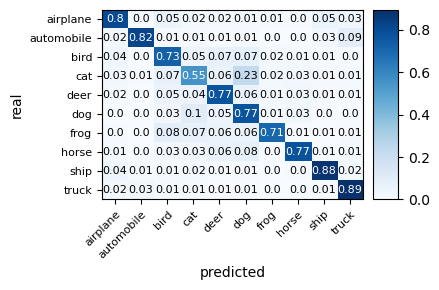

In [58]:
%matplotlib inline

import matplotlib.pyplot as plt

a["validation/iid/confusion"].to_matplotlib()
plt.show()

In [59]:
task.validate().items()

100%|██████████| 78/78 [00:00<00:00, 279.24it/s]


Validation accuracy on iid: 0.7698803659394793


100%|██████████| 78/78 [00:00<00:00, 284.19it/s]

Validation accuracy on train: 0.9890419221875942


dict_items([('iid/loss', 2.015584128195645), ('iid/accuracy', 0.7698803659394793), ('iid/confusion', <framework.visualize.plot.ConfusionMatrix object at 0x7f166ccf5b50>), ('train/loss', 0.007873566117784501), ('train/accuracy', 0.9890419221875942), ('train/confusion', <framework.visualize.plot.ConfusionMatrix object at 0x7f1505881190>), ('mean_accuracy', 0.8794611440635367), ('mean_loss', 1.0117288471567147)])

In [60]:
stage = 0
task.model.set_active(stage)
test, b = task.validate_on(task.valid_sets.iid, task.valid_loaders.iid) 

confusion = test.confusion.type(torch.float32)
confusion = (confusion / confusion.sum(dim=0, keepdim=True)).transpose(1, 0)
if stage == 0:
    confusion_ref = confusion

100%|██████████| 78/78 [00:00<00:00, 253.16it/s]


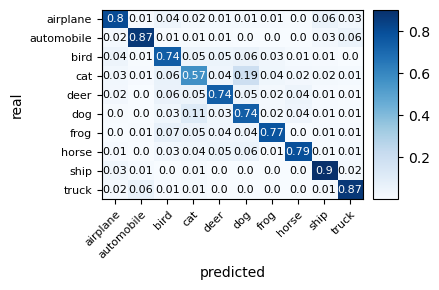

In [61]:
task.draw_confusion_heatmap(confusion_ref).to_matplotlib()
plt.show()

In [62]:
for x in task.model.model_parameters.items():
    print(x)

('features_0_bias', Parameter containing:
tensor([-0.1569, -0.2825,  0.0284, -0.0919, -0.0246,  0.2182, -0.4137,  0.2177,
        -0.0014, -0.4621, -0.0800, -0.1742, -0.0637, -0.2119,  0.0321,  0.2556,
        -0.3725, -0.0770, -0.1721,  0.1505,  0.0015, -0.1227, -0.7462, -0.1355,
        -0.0887,  0.0207, -0.5367,  0.0093, -0.1230, -0.0576, -0.0104, -0.0648],
       device='cuda:0', requires_grad=True))
('features_0_weight', Parameter containing:
tensor([[[[-2.2723e-01, -3.2396e-01, -2.8907e-01],
          [-3.6144e-01, -3.7683e-04, -1.5948e-01],
          [ 2.5835e-01,  3.4342e-01, -4.4594e-02]],

         [[-8.0083e-02, -1.5270e-01, -7.4935e-02],
          [-7.3472e-02,  1.8852e-01, -8.2471e-02],
          [ 2.7606e-01,  2.0988e-01,  6.7567e-02]],

         [[-2.3453e-01, -1.2139e-01, -2.6941e-01],
          [-1.8194e-01,  1.8631e-01,  1.4187e-01],
          [ 2.4661e-01,  3.2559e-01,  1.7005e-01]]],


        [[[ 1.3648e-01,  1.5420e-01, -8.4286e-02],
          [-9.3319e-02,  1.828

In [63]:
stage = 2
task.model.set_active(stage)
test, b = task.validate_on(task.valid_sets.iid, task.valid_loaders.iid)
confusion = test.confusion.type(torch.float32)
confusion = (confusion / confusion.sum(dim=0, keepdim=True)).transpose(1, 0)

100%|██████████| 78/78 [00:00<00:00, 260.72it/s]


In [64]:
diff = confusion - confusion_ref

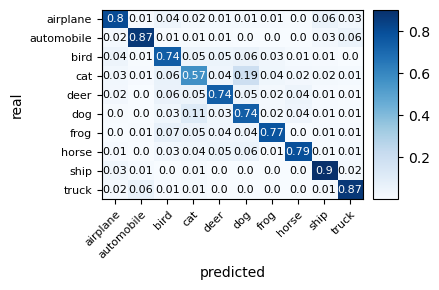

In [65]:
task.draw_confusion_heatmap(confusion_ref).to_matplotlib()
plt.show()

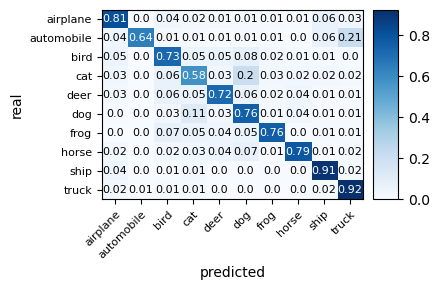

In [66]:
task.draw_confusion_heatmap(confusion).to_matplotlib()
plt.show()

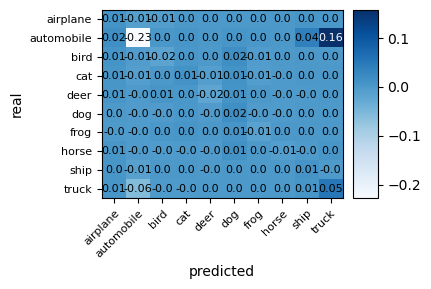

In [67]:
task.draw_confusion_heatmap(diff).to_matplotlib()
plt.show()

In [68]:
task.train_set.n_classes

10

In [70]:
for stage, mask_id in enumerate([-1]+task.mask_classes):
    print([i for i in range(task.train_set.n_classes) if i != mask_id])

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[1, 2, 3, 4, 5, 6, 7, 8, 9]
[0, 2, 3, 4, 5, 6, 7, 8, 9]
[0, 1, 3, 4, 5, 6, 7, 8, 9]
[0, 1, 2, 4, 5, 6, 7, 8, 9]
[0, 1, 2, 3, 5, 6, 7, 8, 9]
[0, 1, 2, 3, 4, 6, 7, 8, 9]
[0, 1, 2, 3, 4, 5, 7, 8, 9]
[0, 1, 2, 3, 4, 5, 6, 8, 9]
[0, 1, 2, 3, 4, 5, 6, 7, 9]
[0, 1, 2, 3, 4, 5, 6, 7, 8]


In [ ]:
task.model.get_masks(1)

{'features_0_bias': tensor([ True,  True,  True,  True,  True,  True,  True,  True, False,  True,
          True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         False,  True,  True,  True,  True,  True,  True,  True,  True,  True,
          True,  True], device='cuda:0'),
 'features_0_weight': tensor([[[[ True,  True,  True],
           [ True, False,  True],
           [ True,  True,  True]],
 
          [[ True,  True,  True],
           [ True,  True,  True],
           [ True,  True,  True]],
 
          [[ True,  True,  True],
           [ True,  True,  True],
           [ True,  True,  True]]],
 
 
         [[[ True,  True,  True],
           [ True,  True,  True],
           [ True,  True,  True]],
 
          [[ True,  True,  True],
           [ True,  True,  True],
           [ True,  True,  True]],
 
          [[ True,  True,  True],
           [ True,  True,  True],
           [ True,  True,  True]]],
 
 
         [[[ True,  True,  True],
           

In [90]:
half = []
inverse = []
for stage, mask_id in enumerate([-1]+task.mask_classes):
    b = task.do_half_mask_test(stage)
    half.append(list(b.values())[0])
    inverse.append(list(b.values())[1])

for stage, mask_id in enumerate([-1]+task.mask_classes):
    print(f"Stage {stage} acc (half/inverse): {half[stage]:2f}  /  {inverse[stage]:2f}")

Half-mask test, stage: split_0, iteration 0: keeping masks for the following layers (6 out of 10): {'features_6_bias', 'features_0_bias', 'features_3_weight', 'features_3_bias', 'features_0_weight', 'features_6_weight'}
Inverse: masking 4 out of 10: {'features_10_weight', 'out_layer_bias', 'out_layer_weight', 'features_10_bias'}


  0%|          | 0/78 [00:00<?, ?it/s]

100%|██████████| 78/78 [00:00<00:00, 254.95it/s]


Half-mask test, stage: split_1, iteration 0: keeping masks for the following layers (6 out of 10): {'features_6_bias', 'features_0_bias', 'features_3_weight', 'features_3_bias', 'features_0_weight', 'features_6_weight'}
Inverse: masking 4 out of 10: {'features_10_weight', 'out_layer_bias', 'out_layer_weight', 'features_10_bias'}


100%|██████████| 78/78 [00:00<00:00, 252.93it/s]


...

Half-mask test, stage: split_9, iteration 0: keeping masks for the following layers (6 out of 10): {'features_6_bias', 'features_0_bias', 'features_3_weight', 'features_3_bias', 'features_0_weight', 'features_6_weight'}
Inverse: masking 4 out of 10: {'features_10_weight', 'out_layer_bias', 'out_layer_weight', 'features_10_bias'}


100%|██████████| 78/78 [00:00<00:00, 270.14it/s]


Half-mask test, stage: split_10, iteration 0: keeping masks for the following layers (6 out of 10): {'features_6_bias', 'features_0_bias', 'features_3_weight', 'features_3_bias', 'features_0_weight', 'features_6_weight'}
Inverse: masking 4 out of 10: {'features_10_weight', 'out_layer_bias', 'out_layer_weight', 'features_10_bias'}


100%|██████████| 78/78 [00:00<00:00, 276.44it/s]

Stage 0 acc (half/inverse): 0.770383  /  0.780436
Stage 1 acc (half/inverse): 0.769780  /  0.732884
Stage 2 acc (half/inverse): 0.769981  /  0.762441
Stage 3 acc (half/inverse): 0.767669  /  0.754901
Stage 4 acc (half/inverse): 0.769478  /  0.749774
Stage 5 acc (half/inverse): 0.770584  /  0.752689
Stage 6 acc (half/inverse): 0.768875  /  0.763748
Stage 7 acc (half/inverse): 0.768674  /  0.750478
Stage 8 acc (half/inverse): 0.769679  /  0.763044
Stage 9 acc (half/inverse): 0.770081  /  0.759928
Stage 10 acc (half/inverse): 0.770081  /  0.764251


In [115]:
task.model.get_masks(1).invert()

{'features_0_bias': tensor([False, False, False, False, False, False, False, False,  True, False,
         False, False, False, False, False, False, False, False, False, False,
          True, False, False, False, False, False, False, False, False, False,
         False, False], device='cuda:0'),
 'features_0_weight': tensor([[[[False, False, False],
           [False,  True, False],
           [False, False, False]],
 
          [[False, False, False],
           [False, False, False],
           [False, False, False]],
 
          [[False, False, False],
           [False, False, False],
           [False, False, False]]],
 
 
         [[[False, False, False],
           [False, False, False],
           [False, False, False]],
 
          [[False, False, False],
           [False, False, False],
           [False, False, False]],
 
          [[False, False, False],
           [False, False, False],
           [False, False, False]]],
 
 
         [[[False, False, False],
           

In [131]:
inverse[10]

{'inverse_mask_test/split_10/iid/loss': 2.302583380393602,
 'inverse_mask_test/split_10/iid/accuracy': 0.0984216346637177,
 'inverse_mask_test/split_10/iid/confusion': <framework.visualize.plot.ConfusionMatrix at 0x7f166d7cb1a0>,
 'inverse_mask_test/split_10/train/loss': 0.571839320615886,
 'inverse_mask_test/split_10/train/accuracy': 0.0976173720719815,
 'inverse_mask_test/split_10/train/confusion': <framework.visualize.plot.ConfusionMatrix at 0x7f166d7fd160>,
 'inverse_mask_test/split_10/mean_accuracy': 0.09801950336784959,
 'inverse_mask_test/split_10/mean_loss': 1.4372113505047441}

In [ ]:
# parser.add_argument("-inv_mask_exclude_io", default="none", choice=["none", "fullmask", "ones"])

inverse = []
for stage, mask_id in enumerate([-1]+task.mask_classes):
    b = task.do_inverse_mask_test(stage)
    inverse.append(b)

Inv mask test. Masks: ['features_0_bias', 'features_0_weight', 'features_10_bias', 'features_10_weight', 'features_3_bias', 'features_3_weight', 'features_6_bias', 'features_6_weight', 'out_layer_bias', 'out_layer_weight'], fallback: []


  0%|          | 0/78 [00:00<?, ?it/s]

100%|██████████| 78/78 [00:00<00:00, 213.59it/s]


Validation accuracy on iid: 0.0984216346637177


100%|██████████| 78/78 [00:00<00:00, 260.56it/s]


...

Validation accuracy on iid: 0.0984216346637177


100%|██████████| 78/78 [00:00<00:00, 254.20it/s]


Validation accuracy on train: 0.0976173720719815


100%|██████████| 78/78 [00:00<00:00, 252.56it/s]

Stage 0 acc (inverse): 0.098422
Stage 1 acc (inverse): 0.098422
Stage 2 acc (inverse): 0.098422
Stage 3 acc (inverse): 0.096411
Stage 4 acc (inverse): 0.098422
Stage 5 acc (inverse): 0.098422
Stage 6 acc (inverse): 0.098422
Stage 7 acc (inverse): 0.098422
Stage 8 acc (inverse): 0.098422
Stage 9 acc (inverse): 0.098422
Stage 10 acc (inverse): 0.098422


In [146]:
for stage, mask_id in enumerate([-1]+task.mask_classes):
    _keys = list(inverse[stage].keys())
    print(f"Stage {stage} acc (inverse): {inverse[stage][_keys[1]]}")

Stage 0 acc (inverse): 0.0984216346637177
Stage 1 acc (inverse): 0.0984216346637177
Stage 2 acc (inverse): 0.0984216346637177
Stage 3 acc (inverse): 0.0964109781843772
Stage 4 acc (inverse): 0.0984216346637177
Stage 5 acc (inverse): 0.0984216346637177
Stage 6 acc (inverse): 0.0984216346637177
Stage 7 acc (inverse): 0.0984216346637177
Stage 8 acc (inverse): 0.0984216346637177
Stage 9 acc (inverse): 0.0984216346637177
Stage 10 acc (inverse): 0.0984216346637177


In [127]:
list(b.keys())

['inverse_mask_test/split_0/iid/loss',
 'inverse_mask_test/split_0/iid/accuracy',
 'inverse_mask_test/split_0/iid/confusion',
 'inverse_mask_test/split_0/train/loss',
 'inverse_mask_test/split_0/train/accuracy',
 'inverse_mask_test/split_0/train/confusion',
 'inverse_mask_test/split_0/mean_accuracy',
 'inverse_mask_test/split_0/mean_loss']

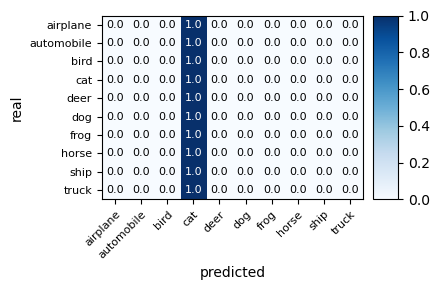

In [100]:
task.draw_confusion_heatmap(b["inverse_mask_test/split_0/iid/confusion"].map).to_matplotlib()
plt.show()

In [ ]:
task.draw

In [65]:
task.model._count_params(task.model.model_parameters.values())

390986

In [66]:
task.model._count_params(task.model.masks[task.model.active].values())

390986

In [67]:
for x in task.model.model_parameters.items():
    print(x)

('features_0_bias', Parameter containing:
tensor([-0.1569, -0.2825,  0.0284, -0.0919, -0.0246,  0.2182, -0.4137,  0.2177,
        -0.0014, -0.4621, -0.0800, -0.1742, -0.0637, -0.2119,  0.0321,  0.2556,
        -0.3725, -0.0770, -0.1721,  0.1505,  0.0015, -0.1227, -0.7462, -0.1355,
        -0.0887,  0.0207, -0.5367,  0.0093, -0.1230, -0.0576, -0.0104, -0.0648],
       device='cuda:0', requires_grad=True))
('features_0_weight', Parameter containing:
tensor([[[[-2.2723e-01, -3.2396e-01, -2.8907e-01],
          [-3.6144e-01, -3.7683e-04, -1.5948e-01],
          [ 2.5835e-01,  3.4342e-01, -4.4594e-02]],

         [[-8.0083e-02, -1.5270e-01, -7.4935e-02],
          [-7.3472e-02,  1.8852e-01, -8.2471e-02],
          [ 2.7606e-01,  2.0988e-01,  6.7567e-02]],

         [[-2.3453e-01, -1.2139e-01, -2.6941e-01],
          [-1.8194e-01,  1.8631e-01,  1.4187e-01],
          [ 2.4661e-01,  3.2559e-01,  1.7005e-01]]],


        [[[ 1.3648e-01,  1.5420e-01, -8.4286e-02],
          [-9.3319e-02,  1.828

In [70]:
task.model.param_names

['features_0_bias',
 'features_0_weight',
 'features_10_bias',
 'features_10_weight',
 'features_3_bias',
 'features_3_weight',
 'features_6_bias',
 'features_6_weight',
 'out_layer_bias',
 'out_layer_weight']

In [ ]:
(mask >= 0).float()

In [75]:
cur_name = task.model.param_names[0]
cur_name

'features_0_bias'

In [76]:
task.model.active_masks[cur_name]

Parameter containing:
tensor([ 2.3174,  3.9697,  0.4132,  3.3613,  2.2453,  2.8714,  3.8088,  3.8719,
        -0.6393,  3.6548,  4.9910,  4.0393,  3.5961,  4.8260,  1.1356,  3.6985,
         4.4922,  2.9287,  5.2778,  2.4476, -0.8486,  3.3488,  4.3024,  4.1370,
         4.1110,  1.2015,  4.5060,  0.6938,  3.8556,  5.2055,  2.1506,  3.7057],
       device='cuda:0', requires_grad=True)

In [77]:
task.model.sample_mask(task.model.active_masks[cur_name], 0)

tensor([1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       device='cuda:0')

In [78]:
task.model.model_parameters[cur_name]

Parameter containing:
tensor([-0.1569, -0.2825,  0.0284, -0.0919, -0.0246,  0.2182, -0.4137,  0.2177,
        -0.0014, -0.4621, -0.0800, -0.1742, -0.0637, -0.2119,  0.0321,  0.2556,
        -0.3725, -0.0770, -0.1721,  0.1505,  0.0015, -0.1227, -0.7462, -0.1355,
        -0.0887,  0.0207, -0.5367,  0.0093, -0.1230, -0.0576, -0.0104, -0.0648],
       device='cuda:0', requires_grad=True)

In [88]:
for x in (task.model.masks[2].parameters()):
    print(x)

Parameter containing:
tensor([ 2.3174,  3.9697,  0.4132,  3.3613,  2.2453,  2.8714,  3.8088,  3.8719,
        -0.6393,  3.6548,  4.9910,  4.0393,  3.5961,  4.8260,  1.1356,  3.6985,
         4.4922,  2.9287,  5.2778,  2.4476, -0.8486,  3.3488,  4.3024,  4.1370,
         4.1110,  1.2015,  4.5060,  0.6938,  3.8556,  5.2055,  2.1506,  3.7057],
       device='cuda:0', requires_grad=True)
Parameter containing:
tensor([[[[  2.6984,   3.2035,   2.9862],
          [  2.4042, -14.2389,   2.1719],
          [  3.2004,   3.0030,   1.4515]],

         [[  2.0980,   2.7016,   2.3548],
          [  1.5191,   2.6862,   1.6778],
          [  3.6216,   3.1991,   2.9729]],

         [[  2.8126,   2.7817,   3.0537],
          [  2.1494,   2.1906,   2.4087],
          [  3.1745,   3.0527,   2.8365]]],


        [[[  3.5272,   3.5161,   1.5764],
          [  1.5901,   2.4141,   2.9324],
          [  2.4661,   3.0975,   1.7673]],

         [[  3.6767,   3.5157,   1.5171],
          [  1.9494,   3.4318,   2.

In [ ]:
model_1 = task.model.masks[0]

# Count total parameters (for comparison)
total_params = sum(p.numel() for p in model_1.parameters() if p.requires_grad)
# Count only nonzero parameters
nonzero_params = sum((p > 0).sum().item() for p in model_1.parameters() if p.requires_grad)

print(f"Total parameters:           {total_params:,}")
print(f"Nonzero parameters:         {nonzero_params:,} --- {round(100 * (nonzero_params / total_params), 2)}%")

Total parameters:           390,986
Nonzero parameters:         192,057
Nonzero parameters (%):     49.12%


In [105]:
task.prepare_model_for_analysis()

# count = 0
for stage, mask_id in enumerate([-1]+task.mask_classes):
    # if count > 1:
    #     break
    # count += 1
    split = "baseline" if stage==0 else task.train_set.class_names[mask_id]

    task.model.set_active(stage)

    set = task.create_restricted_train_set([i for i in range(task.train_set.n_classes) if i != mask_id])
    task.create_validate_on_train(set)

    print(f"stage/mask_id: {stage}/{mask_id}")

    model_1 = task.model.masks[stage]
    nonzero_params = sum((p > 0).sum().item() for p in model_1.parameters() if p.requires_grad)

    print(f"Nonzero parameters:   {nonzero_params:,} --- {round(100 * (nonzero_params / total_params), 2)}%")

    # If mask is finished training
    test, _ = task.validate_on(task.valid_sets.iid, task.valid_loaders.iid)
    print(f"Self-class accuracy: {test.accuracy}")

    print("#######################")
        

stage/mask_id: 0/-1
Nonzero parameters:   191,348 --- 48.94%


100%|██████████| 78/78 [00:00<00:00, 168.18it/s]


Self-class accuracy: 0.780938976575852
#######################
stage/mask_id: 1/0
Nonzero parameters:   189,020 --- 48.34%


100%|██████████| 78/78 [00:00<00:00, 185.46it/s]


Self-class accuracy: 0.7323816225997788
#######################
stage/mask_id: 2/1
Nonzero parameters:   192,057 --- 49.12%


...

Self-class accuracy: 0.7589222881270735
#######################
stage/mask_id: 9/8
Nonzero parameters:   191,037 --- 48.86%


100%|██████████| 78/78 [00:00<00:00, 174.79it/s]


Self-class accuracy: 0.7532924499849201
#######################
stage/mask_id: 10/9
Nonzero parameters:   190,825 --- 48.81%


100%|██████████| 78/78 [00:00<00:00, 179.06it/s]

Self-class accuracy: 0.7590228209510406
#######################


In [102]:
test.accuracy

0.7323816225997788

/home/Raffew/miniconda3/envs/csordas_test/lib/python3.12/site-packages/torch/utils/data/sampler.py:74: UserWarning: `data_source` argument is not used and will be removed in 2.2.0.You may still have custom implementation that utilizes it.
  warnings.warn(


Stage info (whatever it is):
stage: 0
mask_id: -1
Nonzero parameters:   191,348 --- 48.94%


100%|██████████| 78/78 [00:00<00:00, 181.25it/s]


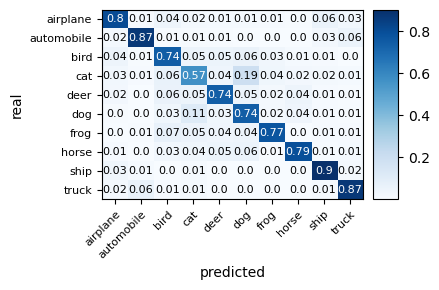

/home/Raffew/miniconda3/envs/csordas_test/lib/python3.12/site-packages/torch/utils/data/sampler.py:74: UserWarning: `data_source` argument is not used and will be removed in 2.2.0.You may still have custom implementation that utilizes it.
  warnings.warn(


Stage info (whatever it is):
stage: 1
mask_id: 0
Nonzero parameters:   189,020 --- 48.34%


100%|██████████| 78/78 [00:00<00:00, 176.34it/s]


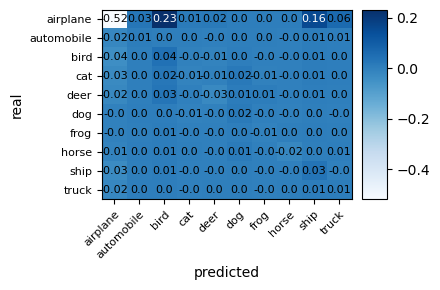

/home/Raffew/miniconda3/envs/csordas_test/lib/python3.12/site-packages/torch/utils/data/sampler.py:74: UserWarning: `data_source` argument is not used and will be removed in 2.2.0.You may still have custom implementation that utilizes it.
  warnings.warn(


Stage info (whatever it is):
stage: 2
mask_id: 1
Nonzero parameters:   192,057 --- 49.12%


100%|██████████| 78/78 [00:00<00:00, 177.77it/s]


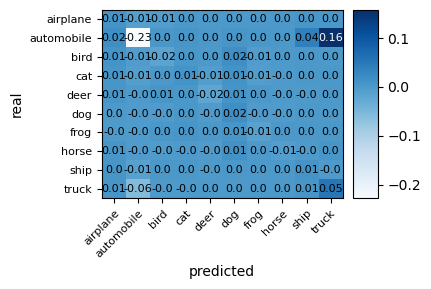

/home/Raffew/miniconda3/envs/csordas_test/lib/python3.12/site-packages/torch/utils/data/sampler.py:74: UserWarning: `data_source` argument is not used and will be removed in 2.2.0.You may still have custom implementation that utilizes it.
  warnings.warn(


Stage info (whatever it is):
stage: 3
mask_id: 2
Nonzero parameters:   186,835 --- 47.79%


100%|██████████| 78/78 [00:00<00:00, 163.28it/s]


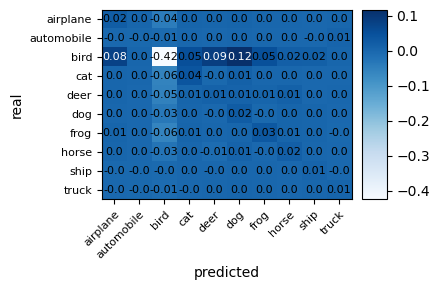

/home/Raffew/miniconda3/envs/csordas_test/lib/python3.12/site-packages/torch/utils/data/sampler.py:74: UserWarning: `data_source` argument is not used and will be removed in 2.2.0.You may still have custom implementation that utilizes it.
  warnings.warn(


Stage info (whatever it is):
stage: 4
mask_id: 3
Nonzero parameters:   185,806 --- 47.52%


100%|██████████| 78/78 [00:00<00:00, 178.28it/s]


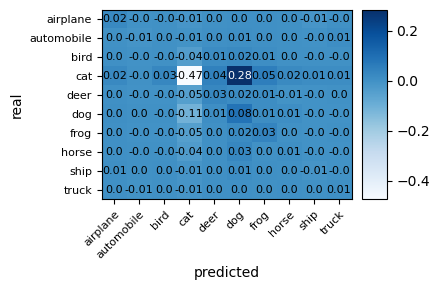

/home/Raffew/miniconda3/envs/csordas_test/lib/python3.12/site-packages/torch/utils/data/sampler.py:74: UserWarning: `data_source` argument is not used and will be removed in 2.2.0.You may still have custom implementation that utilizes it.
  warnings.warn(


Stage info (whatever it is):
stage: 5
mask_id: 4
Nonzero parameters:   188,545 --- 48.22%


100%|██████████| 78/78 [00:00<00:00, 181.04it/s]


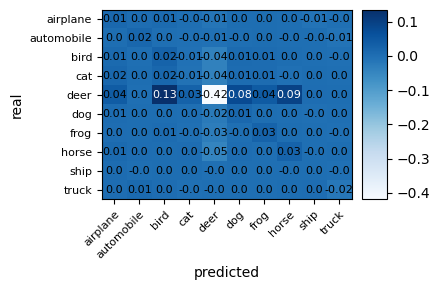

/home/Raffew/miniconda3/envs/csordas_test/lib/python3.12/site-packages/torch/utils/data/sampler.py:74: UserWarning: `data_source` argument is not used and will be removed in 2.2.0.You may still have custom implementation that utilizes it.
  warnings.warn(


Stage info (whatever it is):
stage: 6
mask_id: 5
Nonzero parameters:   187,681 --- 48.0%


100%|██████████| 78/78 [00:00<00:00, 176.41it/s]


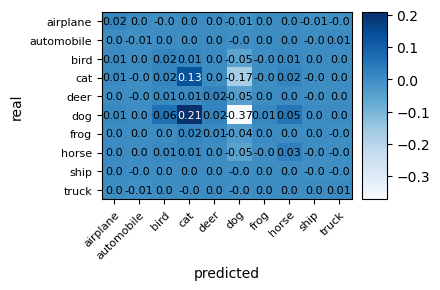

/home/Raffew/miniconda3/envs/csordas_test/lib/python3.12/site-packages/torch/utils/data/sampler.py:74: UserWarning: `data_source` argument is not used and will be removed in 2.2.0.You may still have custom implementation that utilizes it.
  warnings.warn(


Stage info (whatever it is):
stage: 7
mask_id: 6
Nonzero parameters:   190,178 --- 48.64%


100%|██████████| 78/78 [00:00<00:00, 180.34it/s]


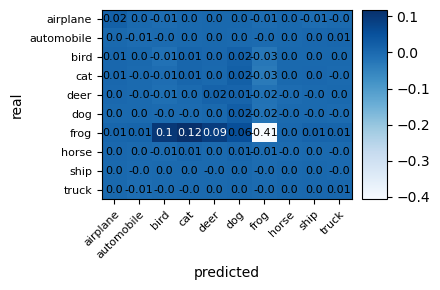

/home/Raffew/miniconda3/envs/csordas_test/lib/python3.12/site-packages/torch/utils/data/sampler.py:74: UserWarning: `data_source` argument is not used and will be removed in 2.2.0.You may still have custom implementation that utilizes it.
  warnings.warn(


Stage info (whatever it is):
stage: 8
mask_id: 7
Nonzero parameters:   189,557 --- 48.48%


100%|██████████| 78/78 [00:00<00:00, 190.12it/s]


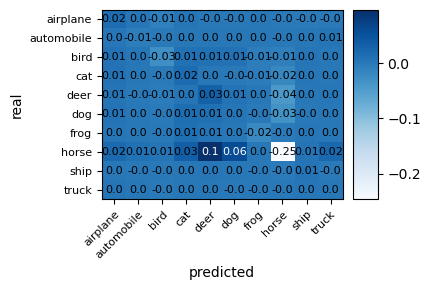

/home/Raffew/miniconda3/envs/csordas_test/lib/python3.12/site-packages/torch/utils/data/sampler.py:74: UserWarning: `data_source` argument is not used and will be removed in 2.2.0.You may still have custom implementation that utilizes it.
  warnings.warn(


Stage info (whatever it is):
stage: 9
mask_id: 8
Nonzero parameters:   191,037 --- 48.86%


100%|██████████| 78/78 [00:00<00:00, 181.01it/s]


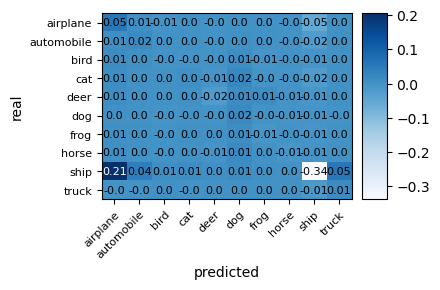

/home/Raffew/miniconda3/envs/csordas_test/lib/python3.12/site-packages/torch/utils/data/sampler.py:74: UserWarning: `data_source` argument is not used and will be removed in 2.2.0.You may still have custom implementation that utilizes it.
  warnings.warn(


Stage info (whatever it is):
stage: 10
mask_id: 9
Nonzero parameters:   190,825 --- 48.81%


100%|██████████| 78/78 [00:00<00:00, 180.65it/s]


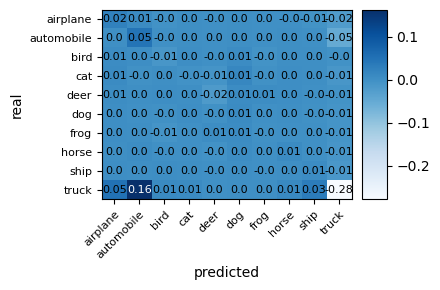

In [94]:
task.prepare_model_for_analysis()

# count = 0
for stage, mask_id in enumerate([-1]+task.mask_classes):
    # if count > 3:
    #     break
    # count += 1
    split = "baseline" if stage==0 else task.train_set.class_names[mask_id]

    task.model.set_active(stage)

    set = task.create_restricted_train_set([i for i in range(task.train_set.n_classes) if i != mask_id])
    task.create_validate_on_train(set)

    print("Stage info (whatever it is):")
    print(f"stage: {stage}")
    print(f"mask_id: {mask_id}")

    model_1 = task.model.masks[stage]
    nonzero_params = sum((p > 0).sum().item() for p in model_1.parameters() if p.requires_grad)

    print(f"Nonzero parameters:   {nonzero_params:,} --- {round(100 * (nonzero_params / total_params), 2)}%")

    # If mask is finished training
    test, _ = task.validate_on(task.valid_sets.iid, task.valid_loaders.iid)
    confusion = test.confusion.type(torch.float32)
    confusion = (confusion / confusion.sum(dim=0, keepdim=True)).transpose(1, 0)
    # Have a reference mask which is all the classes?
    if stage == 0:
        confusion_ref = confusion
        task.draw_confusion_heatmap(confusion_ref).to_matplotlib()
        plt.show()
    else:
        diff = confusion - confusion_ref
        task.draw_confusion_heatmap(diff).to_matplotlib()
        plt.show()

In [79]:
from pathlib import Path

rundir = "./save/cifar10/export/stage_final_masks/"

In [80]:
p = Path(Path.cwd() / rundir)
p

PosixPath('/home/Raffew/Projects/Csordas_modules/save/cifar10/export/stage_final_masks')

In [81]:
num_folders = len([1 for entry in Path(rundir).iterdir() if entry.is_dir()])
num_folders

11

In [82]:
for stage in range(num_folders):
    weights = [torch.load(w, weights_only=False).reshape(-1) for w in Path().glob(f"{rundir}/stage_{stage}/**/*.pth")]
    print(weights)
    break

[array([ 2.6369717 ,  4.2277794 ,  0.32757622,  3.3867707 ,  2.202412  ,
        2.7907357 ,  3.9601774 ,  3.8849027 , -0.87059575,  3.628717  ,
        4.8582044 ,  3.914536  ,  3.7285867 ,  4.91843   ,  0.96754944,
        3.8703272 ,  4.6419497 ,  2.9565852 ,  5.281751  ,  2.3181372 ,
       -0.9727629 ,  3.207938  ,  4.378098  ,  4.164818  ,  4.1138935 ,
        1.380721  ,  4.4770722 ,  0.7525988 ,  4.090915  ,  5.2594066 ,
        2.1235492 ,  3.7790024 ], dtype=float32), array([  2.7225559 ,   3.02551   ,   2.849883  ,   2.5457292 ,
       -14.275013  ,   2.276333  ,   3.0462253 ,   3.1276858 ,
         1.4251386 ,   2.1693234 ,   2.608265  ,   2.3473783 ,
         1.5338578 ,   2.5995681 ,   1.6134914 ,   3.4293299 ,
         3.0120208 ,   2.8966882 ,   2.6364508 ,   2.8086507 ,
         3.1172192 ,   2.316188  ,   2.3552263 ,   2.4949074 ,
         3.074001  ,   3.0390007 ,   2.8033593 ,   3.5945482 ,
         3.423007  ,   1.5939145 ,   1.5494925 ,   2.4914427 ,
         2.97

In [32]:
for stage in range(num_folders):
    weights = [torch.load(w, weights_only=False).reshape(-1) for w in Path().glob(f"{rundir}/stage_{stage}/**/*.pth")]

    # Put all weights in one long list
    weights = np.concatenate(weights)

    # Normalize weights to count all weight (otherwise some are skipped when binning)
    # This seems to work fine...
    m = 1 / (1 + np.exp(-weights))

    removed_params = np.histogram(m, 500, [0, 1])[0][0]
    subnetwork_params = np.sum(np.histogram(m, 500, [0, 1])[0][1:])

    print(f"Percent removed: {removed_params / (subnetwork_params + removed_params)}")

Percent removed: 0.34222964505122944
Percent removed: 0.3443806172088003
Percent removed: 0.34179740451064744
Percent removed: 0.3464906671850143
Percent removed: 0.34737305172052196
Percent removed: 0.34509419774621086
Percent removed: 0.34585125810131306
Percent removed: 0.3434163883105789
Percent removed: 0.34404812448527566
Percent removed: 0.3428306895899086
Percent removed: 0.3430429734056974


In [86]:
weights = [torch.load(w, weights_only=False).reshape(-1) for w in Path().glob(f"{rundir}/stage_1/**/*.pth")]
# weights = [w for w in Path.glob(f"{p.__str__}/stage_0/**/*.pth")]
weights

[array([ 2.3529088 ,  4.0460634 ,  0.29930866,  3.452826  ,  2.2979074 ,
         2.9423738 ,  3.7979302 ,  3.8108356 , -0.8653083 ,  3.5365276 ,
         4.819291  ,  3.8295949 ,  3.629248  ,  4.935815  ,  1.2193033 ,
         3.761887  ,  4.487325  ,  2.9524884 ,  5.1569347 ,  2.5424967 ,
        -0.8541051 ,  3.023793  ,  4.3275857 ,  4.21494   ,  4.2139063 ,
         1.3322865 ,  4.4256907 ,  0.42853764,  4.1756988 ,  5.2212677 ,
         1.7896497 ,  3.5875025 ], dtype=float32),
 array([ 2.9596775e+00,  3.1336131e+00,  2.9014556e+00,  2.7216134e+00,
        -1.4109180e+01,  2.4694803e+00,  2.8340967e+00,  2.9817593e+00,
         1.4188073e+00,  2.3028858e+00,  2.5539925e+00,  2.3326828e+00,
         1.6597555e+00,  2.4732788e+00,  1.6643367e+00,  3.2969420e+00,
         3.1256323e+00,  2.7105818e+00,  2.8244302e+00,  2.9467897e+00,
         2.8795838e+00,  2.2002006e+00,  2.2148609e+00,  2.3641880e+00,
         3.0414598e+00,  2.9089832e+00,  2.8373864e+00,  3.5836027e+00,
       

In [87]:
weights = np.concatenate(weights)
weights

array([  2.3529088 ,   4.0460634 ,   0.29930866, ...,   2.1709478 ,
        -4.600502  , -18.398285  ], shape=(390986,), dtype=float32)

In [75]:
m = 1 / (1 + np.exp(-weights))

In [89]:
np.histogram(weights, 500, [0, 1])

(array([ 89,  78, 122,  90,  97,  87,  91,  82, 114,  99,  98,  94, 103,
         77, 112, 109, 111, 108,  92, 100,  85, 111,  81, 101,  96,  95,
         98, 102,  95, 113, 109,  85,  98, 118,  91, 109, 118, 113, 107,
        105,  78, 103, 105, 107, 104, 106, 107, 107, 110,  89,  91, 101,
         73, 100, 117, 107, 102, 101, 128, 108, 112, 112,  95, 105,  85,
         88,  98,  92,  97, 102,  96, 111, 115, 111, 120, 119, 125, 109,
        114, 113, 116, 119,  90, 116, 121, 117, 132, 119, 109, 111, 109,
        108, 126, 117, 103, 100,  88, 102,  98, 111, 108, 117, 105, 111,
        112, 128, 124, 108, 111, 114, 112, 114, 120, 107, 132, 109, 128,
        103, 132, 116, 127, 102, 106, 123, 112, 129,  99, 117, 144, 107,
        119, 137, 116, 126, 142, 137,  98, 138, 141, 136, 110, 111, 117,
        136, 125, 118, 115, 137, 102, 134, 112, 133, 141, 114, 116, 133,
        113, 118, 132, 105, 134, 139, 119, 126, 108, 125, 131, 109, 140,
        124, 128, 131, 133, 110, 128, 129, 133, 119

In [90]:
np.sum(np.histogram(weights, 500, [0, 1])[0][1:])

np.int64(74931)

In [77]:
removed_params = np.histogram(m, 500, [0, 1])[0][0]
removed_params

np.int64(134648)

In [78]:
subnetwork_params = np.sum(np.histogram(m, 500, [0, 1])[0][1:])
subnetwork_params

np.int64(256338)

In [80]:
print(f"Percent left: {subnetwork_params / (subnetwork_params + removed_params)}")

Percent left: 0.6556193827911997


In [72]:
path = "./save/cifar10/export/stage_final_masks/stage_2/features_6_weight.pth"
test = torch.load(path, weights_only=False)

In [73]:
test

array([[[[ 2.05373836e+00, -1.03672609e+01,  1.01794279e+00],
         [ 7.92350650e-01, -1.74714546e+01,  1.74751949e+00],
         [ 7.01578557e-01,  1.49963844e+00,  1.30932999e+00]],

        [[ 4.11228687e-02,  1.25963402e+00,  6.74690604e-01],
         [ 5.77976644e-01,  8.62409472e-01,  1.03744125e+00],
         [-4.42614734e-01, -7.40990162e+00,  1.74375582e+00]],

        [[ 1.65022266e+00,  1.59015715e+00,  1.77069950e+00],
         [ 2.04650593e+00,  1.52383208e+00,  2.28557634e+00],
         [ 2.38530850e+00,  2.31130838e+00,  2.44099927e+00]],

        ...,

        [[ 1.35388708e+00,  2.08077693e+00, -1.68409526e+00],
         [-2.99847990e-01,  2.28239703e+00,  1.59246194e+00],
         [ 8.46639752e-01,  1.95564017e-01,  1.50029063e+00]],

        [[ 1.24688840e+00, -1.62476850e+00,  1.50988495e+00],
         [ 1.76323891e+00,  2.32582259e+00,  2.13522506e+00],
         [ 7.54849792e-01,  1.23796940e+00,  1.18098474e+00]],

        [[ 9.94476974e-01,  1.05932963e+00,  3

# NOTES

When looking at the 11 "masks", the first mask is a mask made to "keep" the output and last layer. Look into "def class_removal_init_masks_and_optim" to see the usage. 

Only dataloaders have a random seed "set", but that is still randomized.

They loos quite a lot of performance in their subnetworks, if i understand their confusion matrices correctly.

Masks are initialized as "2.0" --> All masks start out the same.

The normalize the data with these tensor values:

MEAN:

    array([[[125.3069 ]],

        [[122.95015]],

        [[113.866  ]]], dtype=float32)

STD:

    array([[[62.992565]],

       [[62.08881 ]],

       [[66.70408 ]]], dtype=float32)

They never change the underlying model parameter values, they only do some "masking magic"